###Executive Dashboard Summary

In [ ]:
# Model performance
best_results = evaluation_results[best_model_name]
print(f"Model Performance ({best_model_name.upper()}):")
print(f"• AUC-ROC Score: {best_results['auc_roc']:.4f}")
print(f"• AUC-PR Score: {best_results['auc_pr']:.4f}")
print(f"• Fraud Detection Rate: {best_results['recall_fraud']:.1%}")
print(f"• False Positive Rate: {1-best_results['precision_fraud']:.1%}")

Model Performance (XGBOOST):
• AUC-ROC Score: 0.9689
• AUC-PR Score: 0.7500
• Fraud Detection Rate: 88.8%
• False Positive Rate: 65.5%


In [ ]:
# Business impact
if 'simulation_results' in locals():
  sim = simulation_results
  fraud_caught = sim[(sim['actual_fraud']==1) & (sim['optimal_flag']==True)]
  total_frauds = sim[sim['actual_fraud']==1]

  if len(total_frauds) > 0:
    catch_rate = len(fraud_caught) / len(total_frauds)
    print(f"\nBusiness Impact:")
    print(f"• Fraud Catch Rate: {catch_rate:.1%}")
    print(f"• Alert Volume: {sim['optimal_flag'].mean():.1%} of transactions")

    if len(fraud_caught) > 0:
      prevented_loss = fraud_caught['amount'].sum()
      print(f"• Prevented Loss (sample): ${prevented_loss:.2f}")


Business Impact:
• Fraud Catch Rate: 95.0%
• Alert Volume: 0.3% of transactions
• Prevented Loss (sample): $14306.63


In [ ]:
# Top risk factors
if 'feature_importance' in locals():
  print(f"\n Top Risk Indicators:")
  for i, row in feature_importance.head(5).iterrows():
    print(f"• {row['feature']}: {row['importance']:.4f}")


 Top Risk Indicators:
• V14: 1.4311
• V4: 1.2474
• PCA_magnitude: 0.7597
• V12: 0.4299
• V10: 0.3652


In [ ]:
# Operational metrics
print(f"\n Operational Metrics:")
print(f"• Training Data: {len(X_train_scaled):,} transactions")
print(f"• Model Features: {len(feature_names)} features")
print(f"• Optimal Threshold: {risk_thresholds['optimal']:.3f}")
print(f"• Conservative Threshold: {risk_thresholds['conservative']:.3f}")


 Operational Metrics:
• Training Data: 227,845 transactions
• Model Features: 46 features
• Optimal Threshold: 0.700
• Conservative Threshold: 0.490


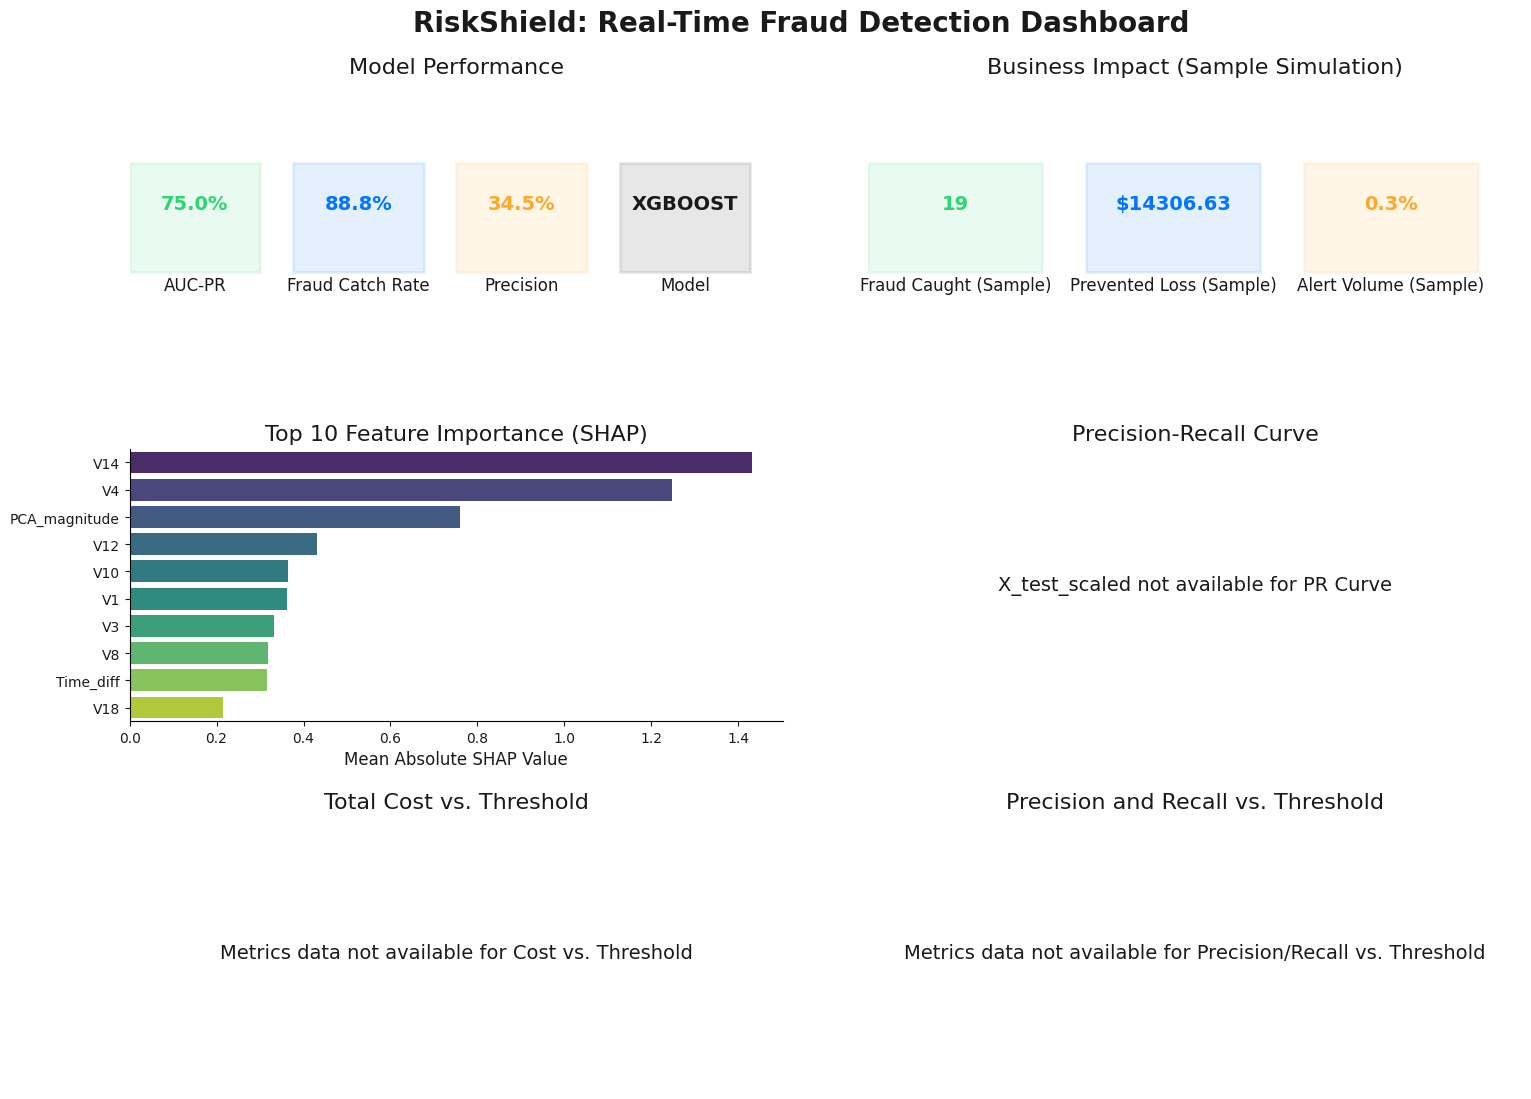

In [ ]:
from matplotlib.patches import Rectangle

plt.style.use('default')
sns.set_palette("husl")

def create_dashboard(evaluation_results, best_model_name, simulation_results, feature_importance, figsize=(16, 12)):
    # Revolut brand colors (approximation)
    REVOLUT_BLUE = '#0075FF'
    REVOLUT_DARK = '#1A1A1A'
    FRAUD_RED = '#FF4757'
    SUCCESS_GREEN = '#2ED573'
    WARNING_ORANGE = '#FFA726'

    fig = plt.figure(figsize=figsize, facecolor='white')
    fig.suptitle('RiskShield: Real-Time Fraud Detection Dashboard',
                 fontsize=20, fontweight='bold', color=REVOLUT_DARK, y=0.98)

    # Create grid layout
    gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.3,
                         left=0.08, right=0.95, top=0.92, bottom=0.08)

    # =================== ROW 1: KEY METRICS ===================

    # 1. Model Performance KPIs
    ax1 = fig.add_subplot(gs[0, 0:2])

    best_results = evaluation_results[best_model_name]

    # KPI boxes
    kpis = [
        ('AUC-PR', best_results['auc_pr'], SUCCESS_GREEN), # Using auc_pr from results
        ('Fraud Catch Rate', best_results['recall_fraud'], REVOLUT_BLUE),
        ('Precision', best_results['precision_fraud'], WARNING_ORANGE),
        ('Model', best_model_name.upper(), REVOLUT_DARK)
    ]

    ax1.set_xlim(0, 4)
    ax1.set_ylim(0, 1)

    for i, (label, value, color) in enumerate(kpis):
        if isinstance(value, float):
            display_value = f'{value:.1%}' if value <= 1 else f'{value:.3f}'
        else:
            display_value = str(value)

        # KPI box
        rect = Rectangle((i, 0.3), 0.8, 0.4, facecolor=color, alpha=0.1, edgecolor=color, linewidth=2)
        ax1.add_patch(rect)

        # Value
        ax1.text(i+0.4, 0.55, display_value, ha='center', va='center',
                fontsize=14, fontweight='bold', color=color)
        # Label
        ax1.text(i+0.4, 0.25, label, ha='center', va='center',
                fontsize=12, color=REVOLUT_DARK)

    ax1.axis('off')
    ax1.set_title('Model Performance', fontsize=16, color=REVOLUT_DARK)


    # 2. Business Impact KPIs
    ax2 = fig.add_subplot(gs[0, 2:4])

    if 'simulation_results' in locals():
      sim = simulation_results
      fraud_caught = sim[(sim['actual_fraud']==1) & (sim['optimal_flag']==True)]
      total_frauds = sim[sim['actual_fraud']==1]

      if len(total_frauds) > 0:
        catch_rate = len(fraud_caught) / len(total_frauds)
        prevented_loss = fraud_caught['amount'].sum() if len(fraud_caught) > 0 else 0

        business_kpis = [
            ('Fraud Caught (Sample)', len(fraud_caught), SUCCESS_GREEN),
            ('Prevented Loss (Sample)', f'${prevented_loss:.2f}', REVOLUT_BLUE),
            ('Alert Volume (Sample)', sim['optimal_flag'].mean(), WARNING_ORANGE)
        ]

        ax2.set_xlim(0, 3)
        ax2.set_ylim(0, 1)

        for i, (label, value, color) in enumerate(business_kpis):
            if isinstance(value, float):
                 display_value = f'{value:.1%}' if value <= 1 else f'{value:.0f}'
            else:
                display_value = str(value)

            rect = Rectangle((i, 0.3), 0.8, 0.4, facecolor=color, alpha=0.1, edgecolor=color, linewidth=2)
            ax2.add_patch(rect)

            ax2.text(i+0.4, 0.55, display_value, ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)
            ax2.text(i+0.4, 0.25, label, ha='center', va='center',
                    fontsize=12, color=REVOLUT_DARK)

        ax2.axis('off')
        ax2.set_title('Business Impact (Sample Simulation)', fontsize=16, color=REVOLUT_DARK)
      else:
        ax2.text(0.5, 0.5, "No frauds in sample", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
        ax2.axis('off')
        ax2.set_title('Business Impact (Sample Simulation)', fontsize=16, color=REVOLUT_DARK)


    # =================== ROW 2: VISUALIZATIONS ===================

    # 3. Feature Importance Plot
    ax3 = fig.add_subplot(gs[1, 0:2])
    if 'feature_importance' in locals():
      top_features = feature_importance.head(10)
      sns.barplot(x='importance', y='feature', data=top_features, ax=ax3, palette='viridis')
      ax3.set_title('Top 10 Feature Importance (SHAP)', fontsize=16, color=REVOLUT_DARK)
      ax3.set_xlabel('Mean Absolute SHAP Value', fontsize=12, color=REVOLUT_DARK)
      ax3.set_ylabel('')
      ax3.tick_params(axis='both', colors=REVOLUT_DARK)
      ax3.spines['top'].set_visible(False)
      ax3.spines['right'].set_visible(False)


    # 4. Precision-Recall Curve
    ax4 = fig.add_subplot(gs[1, 2:4])
    if best_model_name in evaluation_results:
        best_model = models[best_model_name]
        # Need X_test_scaled for prediction, assuming it's available
        if 'X_test_scaled' in locals():
            y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
            precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
            pr_auc = auc(recall, precision)

            ax4.plot(recall, precision, color=REVOLUT_BLUE, lw=2, label=f'{best_model_name.upper()} (AUC = {pr_auc:.2f})')
            ax4.set_xlabel('Recall', fontsize=12, color=REVOLUT_DARK)
            ax4.set_ylabel('Precision', fontsize=12, color=REVOLUT_DARK)
            ax4.set_title('Precision-Recall Curve', fontsize=16, color=REVOLUT_DARK)
            ax4.legend(loc='lower left')
            ax4.set_ylim([0.0, 1.05])
            ax4.set_xlim([0.0, 1.0])
            ax4.grid(True, linestyle='--', alpha=0.6)
            ax4.tick_params(axis='both', colors=REVOLUT_DARK)
            ax4.spines['top'].set_visible(False)
            ax4.spines['right'].set_visible(False)
        else:
             ax4.text(0.5, 0.5, "X_test_scaled not available for PR Curve", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
             ax4.axis('off')
             ax4.set_title('Precision-Recall Curve', fontsize=16, color=REVOLUT_DARK)


    # =================== ROW 3: THRESHOLD ANALYSIS ===================

    # 5. Cost vs. Threshold
    ax5 = fig.add_subplot(gs[2, 0:2])
    if 'metrics' in locals():
      costs = [m['cost'] for m in metrics]
      thresholds = [m['threshold'] for m in metrics]
      ax5.plot(thresholds, costs, color=REVOLUT_BLUE, lw=2)
      ax5.axvline(x=optimal_threshold, color=FRAUD_RED, linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
      ax5.set_xlabel('Threshold', fontsize=12, color=REVOLUT_DARK)
      ax5.set_ylabel('Total Cost ($)', fontsize=12, color=REVOLUT_DARK)
      ax5.set_title('Total Cost vs. Threshold', fontsize=16, color=REVOLUT_DARK)
      ax5.legend()
      ax5.grid(True, linestyle='--', alpha=0.6)
      ax5.tick_params(axis='both', colors=REVOLUT_DARK)
      ax5.spines['top'].set_visible(False)
      ax5.spines['right'].set_visible(False)
    else:
      ax5.text(0.5, 0.5, "Metrics data not available for Cost vs. Threshold", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
      ax5.axis('off')
      ax5.set_title('Total Cost vs. Threshold', fontsize=16, color=REVOLUT_DARK)


    # 6. Precision/Recall vs. Threshold
    ax6 = fig.add_subplot(gs[2, 2:4])
    if 'metrics' in locals():
      precision_vals = [m['precision'] for m in metrics]
      recall_vals = [m['recall'] for m in metrics]
      thresholds = [m['threshold'] for m in metrics]

      ax6.plot(thresholds, precision_vals, color=SUCCESS_GREEN, lw=2, label='Precision')
      ax6.plot(thresholds, recall_vals, color=FRAUD_RED, lw=2, label='Recall')
      ax6.axvline(x=optimal_threshold, color=REVOLUT_BLUE, linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')

      ax6.set_xlabel('Threshold', fontsize=12, color=REVOLUT_DARK)
      ax6.set_ylabel('Score', fontsize=12, color=REVOLUT_DARK)
      ax6.set_title('Precision and Recall vs. Threshold', fontsize=16, color=REVOLUT_DARK)
      ax6.legend()
      ax6.set_ylim([0.0, 1.05])
      ax6.grid(True, linestyle='--', alpha=0.6)
      ax6.tick_params(axis='both', colors=REVOLUT_DARK)
      ax6.spines['top'].set_visible(False)
      ax6.spines['right'].set_visible(False)
    else:
      ax6.text(0.5, 0.5, "Metrics data not available for Precision/Recall vs. Threshold", ha='center', va='center', fontsize=14, color=REVOLUT_DARK)
      ax6.axis('off')
      ax6.set_title('Precision and Recall vs. Threshold', fontsize=16, color=REVOLUT_DARK)


    plt.show()

# Display the dashboard
create_dashboard(evaluation_results, best_model_name, simulation_results, feature_importance)